# PCA

In [1]:
import numpy as np
import pandas as pd

In [2]:
df_train = pd.read_csv("/Users/zulidobariya/Desktop/6th_sem/ADML/data_set_ALL_AML_train.csv")
df = pd.read_csv("/Users/zulidobariya/Desktop/6th_sem/ADML/actual.csv")
df_independent = pd.read_csv("/Users/zulidobariya/Desktop/6th_sem/ADML/data_set_ALL_AML_independent.csv")

In [3]:
df_train.head()

,Gene Description,Gene Accession Number,1,call,2,call.1,3,call.2,4,call.3,...,29,call.33,30,call.34,31,call.35,32,call.36,33,call.37
0,AFFX-BioB-5_at (endogenous control),AFFX-BioB-5_at,-214,A,-139,A,-76,A,-135,A,...,15,A,-318,A,-32,A,-124,A,-135,A
1,AFFX-BioB-M_at (endogenous control),AFFX-BioB-M_at,-153,A,-73,A,-49,A,-114,A,...,-114,A,-192,A,-49,A,-79,A,-186,A
2,AFFX-BioB-3_at (endogenous control),AFFX-BioB-3_at,-58,A,-1,A,-307,A,265,A,...,2,A,-95,A,49,A,-37,A,-70,A
3,AFFX-BioC-5_at (endogenous control),AFFX-BioC-5_at,88,A,283,A,309,A,12,A,...,193,A,312,A,230,P,330,A,337,A
4,AFFX-BioC-3_at (endogenous control),AFFX-BioC-3_at,-295,A,-264,A,-376,A,-419,A,...,-51,A,-139,A,-367,A,-188,A,-407,A


In [4]:
df.head()

,patient,cancer
0,1,ALL
1,2,ALL
2,3,ALL
3,4,ALL
4,5,ALL


In [5]:
df_independent.head()

,Gene Description,Gene Accession Number,39,call,40,call.1,42,call.2,47,call.3,...,65,call.29,66,call.30,63,call.31,64,call.32,62,call.33
0,AFFX-BioB-5_at (endogenous control),AFFX-BioB-5_at,-342,A,-87,A,22,A,-243,A,...,-62,A,-58,A,-161,A,-48,A,-176,A
1,AFFX-BioB-M_at (endogenous control),AFFX-BioB-M_at,-200,A,-248,A,-153,A,-218,A,...,-198,A,-217,A,-215,A,-531,A,-284,A
2,AFFX-BioB-3_at (endogenous control),AFFX-BioB-3_at,41,A,262,A,17,A,-163,A,...,-5,A,63,A,-46,A,-124,A,-81,A
3,AFFX-BioC-5_at (endogenous control),AFFX-BioC-5_at,328,A,295,A,276,A,182,A,...,141,A,95,A,146,A,431,A,9,A
4,AFFX-BioC-3_at (endogenous control),AFFX-BioC-3_at,-224,A,-226,A,-211,A,-289,A,...,-256,A,-191,A,-172,A,-496,A,-294,A


In [6]:
df_train.describe()

,1,2,3,4,5,6,7,8,9,10,...,35,36,37,38,28,29,30,31,32,33
count,7129.000000,7129.000000,7129.000000,7129.000000,7129.000000,7129.000000,7129.000000,7129.000000,7129.000000,7129.000000,...,7129.000000,7129.000000,7129.000000,7129.000000,7129.000000,7129.000000,7129.000000,7129.000000,7129.000000,7129.000000
mean,641.367092,690.246318,698.307897,600.985271,679.532894,564.797728,584.437649,571.359097,789.713705,599.483097,...,514.496704,775.143498,689.248141,626.885959,673.279422,556.463179,718.934493,598.648899,676.920887,723.563473
std,2264.294361,2468.814372,2485.656277,2340.047428,2375.895416,2494.604090,2412.812263,2378.780450,2580.157021,2421.156219,...,2440.722824,2676.664777,2543.537830,2473.180838,2413.149603,2376.681824,2533.678058,2405.268550,2436.964933,2507.382019
min,-19826.000000,-17930.000000,-27182.000000,-23396.000000,-10339.000000,-21658.000000,-24024.000000,-27570.000000,-25171.000000,-12500.000000,...,-16281.000000,-27398.000000,-23673.000000,-23645.000000,-20376.000000,-9501.000000,-17580.000000,-25491.000000,-28400.000000,-27811.000000
25%,-21.000000,-14.000000,-31.000000,-33.000000,8.000000,-26.000000,-33.000000,-58.000000,-14.000000,-15.000000,...,-43.000000,-27.000000,-23.000000,-22.000000,-16.000000,-13.000000,-25.000000,-32.000000,-22.000000,-38.000000
50%,159.000000,130.000000,177.000000,139.000000,146.000000,106.000000,134.000000,140.000000,166.000000,103.000000,...,108.000000,144.000000,134.000000,133.000000,150.000000,82.000000,128.000000,107.000000,155.000000,170.000000
75%,535.000000,488.000000,610.000000,497.000000,471.000000,401.000000,497.000000,527.000000,609.000000,386.000000,...,396.000000,569.000000,505.000000,490.000000,517.000000,309.000000,488.000000,443.000000,549.000000,649.000000
max,31086.000000,29288.000000,28056.000000,31449.000000,29543.000000,38467.000000,41911.000000,40065.000000,23602.000000,28033.000000,...,61228.000000,37164.000000,32204.000000,29169.000000,29833.000000,30354.000000,25055.000000,28350.000000,25093.000000,32946.000000


In [7]:
df.describe()

,patient
count,72.00000
mean,36.50000
std,20.92845
min,1.00000
25%,18.75000
50%,36.50000
75%,54.25000
max,72.00000


In [8]:
df_independent.describe()

,39,40,42,47,48,49,41,43,44,45,...,54,57,58,60,61,65,66,63,64,62
count,7129.000000,7129.000000,7129.000000,7129.000000,7129.000000,7129.000000,7129.000000,7129.000000,7129.000000,7129.000000,...,7129.00000,7129.000000,7129.000000,7129.000000,7129.000000,7129.000000,7129.000000,7129.000000,7129.000000,7129.00000
mean,582.194978,527.819329,603.813719,576.027213,751.464862,601.516763,565.152476,563.614252,531.401599,530.194137,...,668.70122,497.195820,561.964371,561.004629,581.006593,556.054145,530.495020,727.593351,686.850610,671.16496
std,2473.986881,2304.800191,2377.775459,2436.848381,2437.815002,2432.454360,2352.036107,2521.409254,2335.848476,2368.906095,...,2505.06701,2436.468032,2688.424072,2615.321812,2467.740997,2360.238246,2463.108827,2488.340963,2703.734409,2659.95898
min,-21984.000000,-21296.000000,-10481.000000,-7861.000000,-16945.000000,-26775.000000,-7764.000000,-13905.000000,-9619.000000,-5353.000000,...,-11978.00000,-11067.000000,-16131.000000,-9338.000000,-16268.000000,-14244.000000,-7626.000000,-20782.000000,-26258.000000,-11973.00000
25%,-33.000000,-36.000000,-17.000000,-8.000000,-6.000000,-65.000000,-7.000000,-21.000000,-45.000000,-59.000000,...,-10.00000,-27.000000,-49.000000,-19.000000,-36.000000,-31.000000,-15.000000,-21.000000,-51.000000,-20.00000
50%,125.000000,124.000000,116.000000,126.000000,158.000000,139.000000,93.000000,110.000000,74.000000,78.000000,...,151.00000,82.000000,129.000000,98.000000,117.000000,99.000000,73.000000,162.000000,195.000000,136.00000
75%,439.000000,424.000000,420.000000,374.000000,577.000000,552.000000,342.000000,372.000000,321.000000,327.000000,...,469.00000,296.000000,435.000000,321.000000,422.000000,366.000000,280.000000,578.000000,683.000000,474.00000
max,45815.000000,29136.000000,37529.000000,43221.000000,25231.000000,29500.000000,31076.000000,49432.000000,35402.000000,34741.000000,...,35742.00000,38690.000000,59647.000000,40792.000000,37374.000000,27447.000000,53204.000000,31585.000000,71369.000000,48374.00000


In [9]:
df.isnull().sum()

patient    0
cancer     0
dtype: int64

In [11]:
df_train.isnull().sum().sum()

0

In [12]:
df_independent.isnull().sum().sum()

0

In [13]:
pd.reset_option('display.max_columns',None)

In [14]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [15]:
df_independent.columns

Index(['Gene Description', 'Gene Accession Number', '39', 'call', '40',
       'call.1', '42', 'call.2', '47', 'call.3', '48', 'call.4', '49',
       'call.5', '41', 'call.6', '43', 'call.7', '44', 'call.8', '45',
       'call.9', '46', 'call.10', '70', 'call.11', '71', 'call.12', '72',
       'call.13', '68', 'call.14', '69', 'call.15', '67', 'call.16', '55',
       'call.17', '56', 'call.18', '59', 'call.19', '52', 'call.20', '53',
       'call.21', '51', 'call.22', '50', 'call.23', '54', 'call.24', '57',
       'call.25', '58', 'call.26', '60', 'call.27', '61', 'call.28', '65',
       'call.29', '66', 'call.30', '63', 'call.31', '64', 'call.32', '62',
       'call.33'],
      dtype='object')

In [16]:
df_Train = df_train.drop(['Gene Description','Gene Accession Number'], axis=1)

In [17]:
trainreq = [col for col in df_Train.columns if "call" not in col]
train = df_Train[trainreq]
train.head()

,1,2,3,4,5,6,7,8,9,10,...,35,36,37,38,28,29,30,31,32,33
0,-214,-139,-76,-135,-106,-138,-72,-413,5,-88,...,7,-213,-25,-72,-4,15,-318,-32,-124,-135
1,-153,-73,-49,-114,-125,-85,-144,-260,-127,-105,...,-100,-252,-20,-139,-116,-114,-192,-49,-79,-186
2,-58,-1,-307,265,-76,215,238,7,106,42,...,-57,136,124,-1,-125,2,-95,49,-37,-70
3,88,283,309,12,168,71,55,-2,268,219,...,132,318,325,392,241,193,312,230,330,337
4,-295,-264,-376,-419,-230,-272,-399,-541,-210,-178,...,-377,-209,-396,-324,-191,-51,-139,-367,-188,-407


In [18]:
train.shape


(7129, 38)

In [19]:
from sklearn.preprocessing import StandardScaler

In [20]:
scaler = StandardScaler()

In [21]:
scaled_X = scaler.fit_transform(train)

In [22]:
scaled_X

array([[-0.3777897 , -0.33591204, -0.3115323 , ..., -0.26221319,
        -0.32867813, -0.34243832],
       [-0.35084785, -0.30917669, -0.30066921, ..., -0.2692815 ,
        -0.31021124, -0.36277969],
       [-0.30888923, -0.28001085, -0.40447202, ..., -0.22853475,
        -0.29297548, -0.31651305],
       ...,
       [-0.26737228, -0.27514987, -0.26445893, ..., -0.25971849,
        -0.26178696, -0.29337973],
       [-0.19891348, -0.2488196 , -0.18922201, ..., -0.19360897,
        -0.15549976,  0.02649823],
       [-0.29961417, -0.2852769 , -0.29745052, ..., -0.26221319,
        -0.27902272, -0.29258203]])

In [23]:
from sklearn.decomposition import PCA

In [24]:
model = PCA(n_components=2)

In [25]:
principal_components = model.fit_transform(scaled_X)

<Figure size 800x600 with 0 Axes>

Text(0.5, 0, 'First principal component')

Text(0, 0.5, 'Second Principal Component')

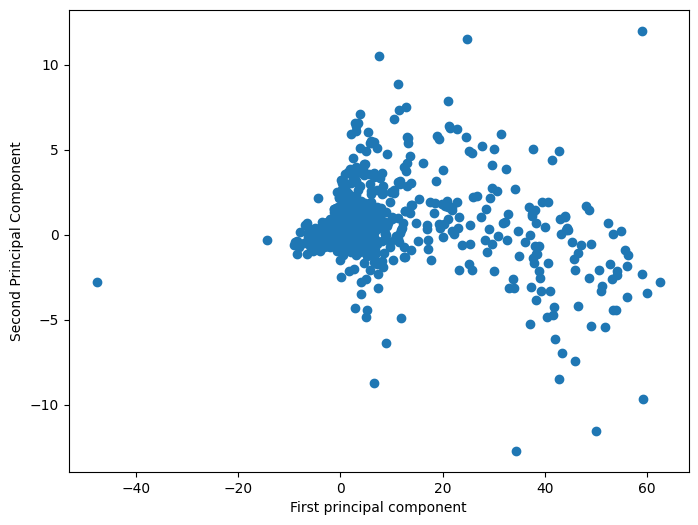

In [27]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.scatter(principal_components[:,0],principal_components[:,1])
plt.xlabel('First principal component')
plt.ylabel('Second Principal Component')

In [28]:
model.n_components

2

In [29]:
model.components_

array([[ 0.16565211,  0.16467099,  0.16134004,  0.16774043,  0.1666586 ,
         0.15736667,  0.1601356 ,  0.16256293,  0.15953018,  0.16292101,
         0.16465717,  0.16514113,  0.16426972,  0.16539859,  0.16449716,
         0.16707326,  0.16028388,  0.16167044,  0.16542269,  0.15289528,
         0.14864335,  0.16167525,  0.15903599,  0.1672952 ,  0.16387506,
         0.16469839,  0.16401245,  0.16523966,  0.15568103,  0.15296476,
         0.15896377,  0.16093739,  0.16588891,  0.16259026,  0.1596499 ,
         0.16528256,  0.16533151,  0.16064192],
       [-0.01867496,  0.08538834, -0.15546421, -0.06610027,  0.02947977,
        -0.26943755, -0.228787  , -0.05791167, -0.00451737, -0.10980975,
        -0.12955861, -0.07237469,  0.03596924, -0.04830284,  0.05284681,
        -0.10125643,  0.09317745, -0.00356397, -0.0474996 ,  0.18179018,
        -0.13143826, -0.09748686, -0.33855185, -0.03663965,  0.07398813,
        -0.01125876, -0.20715584,  0.08000551, -0.24045762,  0.3732212 ,
   

In [30]:
df_comp = pd.DataFrame(model.components_,index=['PC1','PC2'],columns=train.columns)


In [31]:
df_comp

,1,2,3,4,5,6,7,8,9,10,...,35,36,37,38,28,29,30,31,32,33
PC1,0.165652,0.164671,0.161340,0.16774,0.166659,0.157367,0.160136,0.162563,0.159530,0.162921,...,0.155681,0.152965,0.158964,0.160937,0.165889,0.162590,0.159650,0.165283,0.165332,0.160642
PC2,-0.018675,0.085388,-0.155464,-0.06610,0.029480,-0.269438,-0.228787,-0.057912,-0.004517,-0.109810,...,-0.240458,0.373221,0.323738,0.093663,0.177672,0.028128,0.325013,0.030733,0.124564,0.277642


<Figure size 3000x450 with 0 Axes>

<Axes: >

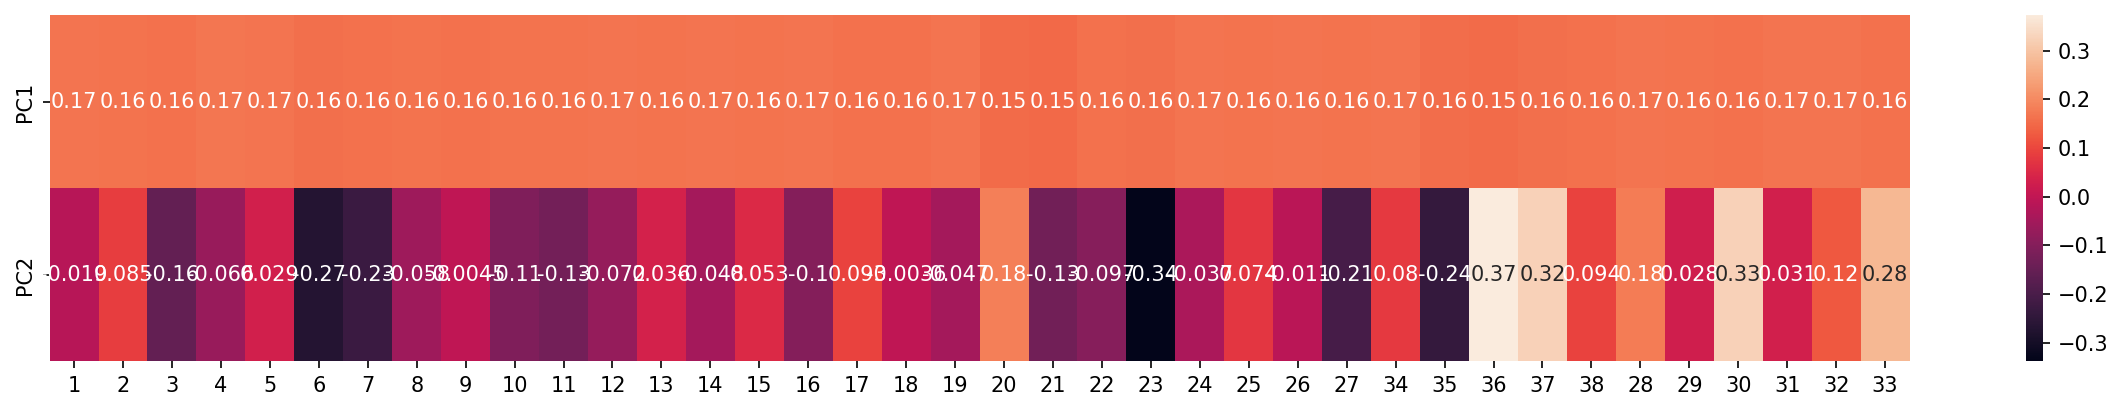

In [33]:
import seaborn as sns
plt.figure(figsize=(20,3),dpi=150)
sns.heatmap(df_comp,annot=True)

In [34]:
model.explained_variance_ratio_

array([0.89187287, 0.0161332 ])

In [35]:
np.sum(model.explained_variance_ratio_)

0.9080060692701364

In [36]:
%%html
<img src="https://static.remove.bg/sample-gallery/graphics/bird-thumbnail.jpg" alt="Sample Image" width="300">

In [37]:
explained_variance = []

for n in range(1,38):
    pca = PCA(n_components=n)
    pca.fit(scaled_X)
    
    explained_variance.append(np.sum(pca.explained_variance_ratio_))

PCA(n_components=1)

PCA(n_components=2)

PCA(n_components=3)

PCA(n_components=4)

PCA(n_components=5)

...

PCA(n_components=33)

PCA(n_components=34)

PCA(n_components=35)

PCA(n_components=36)

PCA(n_components=37)

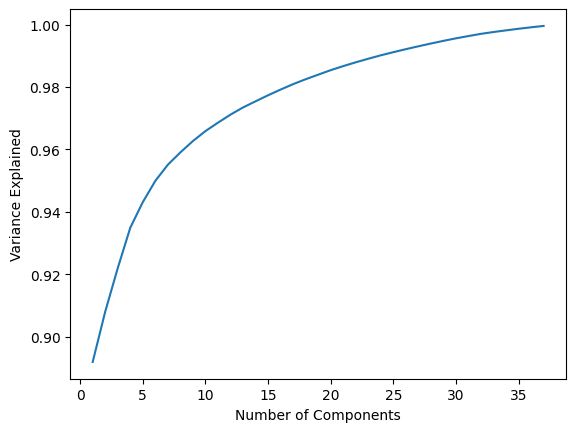

In [38]:
plt.plot(range(1,38),explained_variance)
plt.xlabel("Number of Components")
plt.ylabel("Variance Explained");